# Brain Tumor MRI: Custom CNN (From Scratch)


##### Imports


In [17]:
import os
import re
import glob
import random
import warnings
from collections import defaultdict
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import cv2
from PIL import Image
import imagehash
import albumentations as A
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

print("TensorFlow version:", tf.__version__)
print("GPU available    :", len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow version: 2.20.0
GPU available    : True


#### Loading the dataset


In [18]:
DATASET_DIR = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
CACHE_DIR   = "/kaggle/working/preprocessed_cache_customcnn"

def find_split_dir(root, keywords):
    matches = []
    for p in glob.glob(os.path.join(root, "**"), recursive=True):
        if os.path.isdir(p) and any(k in os.path.basename(p).lower() for k in keywords):
            matches.append((p.replace(root, "").count(os.sep), p))
    matches.sort(key=lambda x: x[0])
    return matches[0][1] if matches else None

TRAIN_DIR = find_split_dir(DATASET_DIR, ["train"]) or "/path/to/your/Training"
TEST_DIR  = find_split_dir(DATASET_DIR, ["test"])  or "/path/to/your/Testing"

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
if not os.path.isdir(TRAIN_DIR) or not os.path.isdir(TEST_DIR):
    print("\n Path not found")

IMG_SIZE   = 224
SEED       = 42

N_GROUP_FOLDS   = 20
TRAIN_FOLDS     = 14
VAL_FOLDS       = 3
TEST_FOLDS      = 3

PHASH_SIZE        = 8
PHASH_MAX_HAMMING = 5

CLASS_KEYWORDS = {
    "glioma":     ["gl"],
    "meningioma": ["me"],
    "notumor":    ["no"],
    "pituitary":  ["pi"],
}
CLASS_NAMES = sorted(CLASS_KEYWORDS.keys())
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {idx: name for name, idx in CLASS_TO_ID.items()}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("Classes:", CLASS_NAMES)


TRAIN_DIR: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
TEST_DIR : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


##### Universal Dataframe + Group-ID Extraction


In [19]:
GROUP_ID_PATTERN = re.compile(r"(\d+)")

def get_class_from_folder(folder_name):
    name_lower = folder_name.lower()
    for class_name, keywords in CLASS_KEYWORDS.items():
        for kw in keywords:
            if kw in name_lower:
                return class_name
    return None

def extract_group_id(filename, class_name):
    stem = os.path.splitext(filename)[0]
    match = GROUP_ID_PATTERN.search(stem)
    numeric_part = match.group(1) if match else stem
    return f"{class_name}_{numeric_part}"

def build_dataframe(root_dir, split_name):
    records = []
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

    for sub_folder in sorted(os.listdir(root_dir)):
        sub_path = os.path.join(root_dir, sub_folder)
        if not os.path.isdir(sub_path):
            continue
        class_name = get_class_from_folder(sub_folder)
        if class_name is None:
            print(f"[WARNING] '{sub_folder}' folder class not found, skipped")
            continue

        for fname in sorted(os.listdir(sub_path)):
            if fname.lower().endswith(valid_ext):
                full_path = os.path.join(sub_path, fname)
                records.append({
                    "image_path": full_path,
                    "label": class_name,
                    "class_id": CLASS_TO_ID[class_name],
                    "original_split": split_name,
                    "group_id": extract_group_id(fname, class_name),
                })

    return pd.DataFrame(records)

train_df_raw = build_dataframe(TRAIN_DIR, "train")
test_df_raw  = build_dataframe(TEST_DIR, "test")
full_df = pd.concat([train_df_raw, test_df_raw], ignore_index=True)

n_groups = full_df["group_id"].nunique()
print("Total images found:", len(full_df))
print("Total distinct group_id (filename-based proxy group, not verified patient ID):", n_groups)
print(f"Avg images per group: {len(full_df) / n_groups:.2f}")
full_df.head()


Total images found: 7200
Total distinct group_id (filename-based proxy group, not verified patient ID): 5500
Avg images per group: 1.31


,image_path,label,class_id,original_split,group_id
0,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_1
1,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_10
2,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_100
3,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_1000
4,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma,0,train,glioma_1001


###### Corrupt Image Check


In [20]:
corrupt_paths = []
for path in full_df["image_path"]:
    img = cv2.imread(path)
    if img is None:
        corrupt_paths.append(path)

print(f"Corrupt / unreadable images found: {len(corrupt_paths)}")
if len(corrupt_paths) > 0:
    full_df = full_df[~full_df["image_path"].isin(corrupt_paths)].reset_index(drop=True)
    print("Corrupt images are removed from dataframe")


Corrupt / unreadable images found: 0


##### Near-Duplicate Removal — Perceptual Hashing


In [21]:
def compute_phash(path, hash_size=PHASH_SIZE):
    try:
        with Image.open(path) as im:
            return imagehash.phash(im.convert("L"), hash_size=hash_size)
    except Exception:
        return None


full_df["phash"] = full_df["image_path"].apply(compute_phash)
n_hash_fail = full_df["phash"].isna().sum()
if n_hash_fail:
    print(f"[WARNING] {n_hash_fail} images for which path not found are dropped")
    full_df = full_df.dropna(subset=["phash"]).reset_index(drop=True)
parent = {i: i for i in full_df.index}

def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i

def union(i, j):
    ri, rj = find(i), find(j)
    if ri != rj:
        parent[rj] = ri

for class_name, group in full_df.groupby("label"):
    idxs = group.index.to_list()
    hashes = group["phash"].to_list()
    for a in range(len(idxs)):
        for b in range(a + 1, len(idxs)):
            if hashes[a] - hashes[b] <= PHASH_MAX_HAMMING:
                union(idxs[a], idxs[b])

full_df["dup_cluster"] = full_df.index.map(find)

n_before = len(full_df)
n_clusters = full_df["dup_cluster"].nunique()
print(f"Images before near-duplicate removal : {n_before}")
print(f"Distinct visual clusters found       : {n_clusters}")
print(f"Near-duplicate images to be dropped  : {n_before - n_clusters}")

cluster_to_group = full_df.groupby("dup_cluster")["group_id"].first()
full_df["group_id"] = full_df["dup_cluster"].map(cluster_to_group)

full_df = full_df.drop_duplicates(subset="dup_cluster", keep="first").reset_index(drop=True)
full_df = full_df.drop(columns=["phash", "dup_cluster"])

print(f"Final unique images: {len(full_df)}")
print(f"Final distinct group_id count: {full_df['group_id'].nunique()}")


Images before near-duplicate removal : 7200
Distinct visual clusters found       : 4784
Near-duplicate images to be dropped  : 2416
Final unique images: 4784
Final distinct group_id count: 4028


##### Patient-Grouped Stratified Split (70 : 15 : 15)


In [22]:
def stratified_group_split_20fold(df, label_col="label", group_col="group_id", seed=SEED):
    skf = StratifiedGroupKFold(n_splits=N_GROUP_FOLDS, shuffle=True, random_state=seed)

    fold_id = np.full(len(df), -1, dtype=int)
    for fold_num, (_, held_out_idx) in enumerate(
        skf.split(df, y=df[label_col], groups=df[group_col])
    ):
        fold_id[held_out_idx] = fold_num

    assert (fold_id >= 0).all(), "fold can not be assigned for some rows - StratifiedGroupKFold issue."

    train_mask = fold_id < TRAIN_FOLDS
    val_mask   = (fold_id >= TRAIN_FOLDS) & (fold_id < TRAIN_FOLDS + VAL_FOLDS)
    test_mask  = fold_id >= (TRAIN_FOLDS + VAL_FOLDS)

    return (
        df[train_mask].reset_index(drop=True),
        df[val_mask].reset_index(drop=True),
        df[test_mask].reset_index(drop=True),
    )


train_df, val_df, test_df = stratified_group_split_20fold(full_df)

print(f"Train: {len(train_df):5d}  ({len(train_df)/len(full_df):.1%})  groups={train_df['group_id'].nunique()}")
print(f"Val  : {len(val_df):5d}  ({len(val_df)/len(full_df):.1%})  groups={val_df['group_id'].nunique()}")
print(f"Test : {len(test_df):5d}  ({len(test_df)/len(full_df):.1%})  groups={test_df['group_id'].nunique()}")

train_paths, val_paths, test_paths = set(train_df["image_path"]), set(val_df["image_path"]), set(test_df["image_path"])
train_groups, val_groups, test_groups = set(train_df["group_id"]), set(val_df["group_id"]), set(test_df["group_id"])

assert len(train_paths & val_paths) == 0,  "Leakage: train/val have common image paths!"
assert len(train_paths & test_paths) == 0, "Leakage: train/test have common image paths!"
assert len(val_paths & test_paths) == 0,   "Leakage: val/test have common image paths!"

assert len(train_groups & val_groups) == 0,  "GROUP Leakage: train/val have same id!"
assert len(train_groups & test_groups) == 0, "GROUP Leakage: train/test have same id!"
assert len(val_groups & test_groups) == 0,   "GROUP Leakage: val/test have same id!"

print("\nLeakage check passed: No data leakage detected")


Train:  3348  (70.0%)  groups=2818
Val  :   706  (14.8%)  groups=604
Test :   730  (15.3%)  groups=606

Leakage check passed: No data leakage detected


##### Offline Preprocessing Cache (Skull-Strip + CLAHE, once, to disk)


In [23]:
def skull_strip(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return img_bgr

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    if w * h < 0.05 * (img_bgr.shape[0] * img_bgr.shape[1]):
        return img_bgr

    return img_bgr[y:y + h, x:x + w]


def apply_clahe(img_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l_channel)
    lab_enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
    return cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)


def preprocess_image_bgr(image_path, size=IMG_SIZE):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Image load can not be loaded: {image_path}")
    stripped = skull_strip(img_bgr)
    enhanced = apply_clahe(stripped)
    resized = cv2.resize(enhanced, (size, size), interpolation=cv2.INTER_AREA)
    return resized


def cache_split(df, split_name, cache_root=CACHE_DIR):
    cached_rows = []
    for i, row in df.reset_index(drop=True).iterrows():
        label = row["label"]
        out_dir = os.path.join(cache_root, split_name, label)
        os.makedirs(out_dir, exist_ok=True)

        out_name = f"{row['group_id']}_{i}.png"
        out_path = os.path.join(out_dir, out_name)

        if not os.path.exists(out_path):
            processed_bgr = preprocess_image_bgr(row["image_path"])
            cv2.imwrite(out_path, processed_bgr)

        new_row = row.to_dict()
        new_row["image_path"] = out_path
        cached_rows.append(new_row)

    return pd.DataFrame(cached_rows)


print("Caching train split (skull-strip + CLAHE, one-time)...")
train_df = cache_split(train_df, "train")
print("Caching val split...")
val_df = cache_split(val_df, "val")
print("Caching test split...")
test_df = cache_split(test_df, "test")

print("\nCaching done. Cached counts:")
print(f"Train: {len(train_df)}   Val: {len(val_df)}   Test: {len(test_df)}")
print(f"Cache directory: {CACHE_DIR}")


Caching train split (skull-strip + CLAHE, one-time)...
Caching val split...
Caching test split...

Caching done. Cached counts:
Train: 3348   Val: 706   Test: 730
Cache directory: /kaggle/working/preprocessed_cache_customcnn


##### Medical-Safe Data Augmentation (Train Split Only)


In [24]:
train_augmentations = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(rotate_limit=15, scale_limit=0.1, shift_limit=0.05, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=IMG_SIZE // 12, max_width=IMG_SIZE // 12, fill_value=0, p=0.3),
])

def _apply_train_augmentation(image_uint8):
    return train_augmentations(image=image_uint8)["image"]


##### Pipeline


In [25]:
BATCH_SIZE = 32
EPOCHS     = 25
AUTOTUNE = tf.data.AUTOTUNE

def _load_and_decode(path):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.uint8)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="area")
    img = tf.cast(img, tf.uint8)
    return img

def _make_map_fn(preprocess_fn, is_train):
    def _map_fn(path, label):
        img = _load_and_decode(path)
        if is_train:
            img = tf.numpy_function(func=_apply_train_augmentation, inp=[img], Tout=tf.uint8)
            img.set_shape([IMG_SIZE, IMG_SIZE, 3])
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)
        label = tf.one_hot(label, depth=len(CLASS_NAMES))
        return img, label
    return _map_fn

def build_tf_dataset(df, is_train, preprocess_fn, batch_size=BATCH_SIZE):
    paths = df["image_path"].values
    labels = df["class_id"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if is_train:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(_make_map_fn(preprocess_fn, is_train=True), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(_make_map_fn(preprocess_fn, is_train=False), num_parallel_calls=AUTOTUNE, deterministic=True)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds
print("Dataset builder ready. Val/Test datasets are strictly ordered + unshuffled for safe evaluation.")


Dataset builder ready. Val/Test datasets are strictly ordered + unshuffled for safe evaluation.


##### Reusable Model Build, Train & Evaluation Functions


In [26]:
def custom_cnn_preprocess(img):
    return img / 255.0


def build_custom_cnn(model_name="CustomCNN"):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", name="predictions")(x)

    model = models.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f"{model_name}_best.keras", monitor="val_accuracy", save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    ]

def get_predictions(model, dataset, df):
    y_pred_probs = model.predict(dataset, verbose=0)
    y_true_ids = df["class_id"].values[: len(y_pred_probs)]
    y_pred_ids = np.argmax(y_pred_probs, axis=1)
    return y_true_ids, y_pred_ids, y_pred_probs


def compute_split_metrics(y_true_ids, y_pred_ids, split_name):
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true_ids, y_pred_ids),
        "precision": precision_score(y_true_ids, y_pred_ids, average="macro", zero_division=0),
        "recall": recall_score(y_true_ids, y_pred_ids, average="macro", zero_division=0),
        "f1": f1_score(y_true_ids, y_pred_ids, average="macro", zero_division=0),
    }


def full_evaluation(model, model_name, train_ds, test_ds, train_df_ref, test_df_ref):
    y_true_tr, y_pred_tr, _ = get_predictions(model, train_ds, train_df_ref)
    train_metrics = compute_split_metrics(y_true_tr, y_pred_tr, "train")

    y_true_te, y_pred_te, y_prob_te = get_predictions(model, test_ds, test_df_ref)
    test_metrics = compute_split_metrics(y_true_te, y_pred_te, "test")

    print(f"\n===== {model_name} - Train Metrics =====")
    for k, v in train_metrics.items():
        if k != "split":
            print(f"{k:>10}: {v:.4f}")

    print(f"\n===== {model_name} - Test Metrics =====")
    for k, v in test_metrics.items():
        if k != "split":
            print(f"{k:>10}: {v:.4f}")

    print(f"\n===== {model_name} - Test Classification Report =====")
    print(classification_report(y_true_te, y_pred_te, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_true_te, y_pred_te)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{model_name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    y_true_bin = label_binarize(y_true_te, classes=list(range(len(CLASS_NAMES))))
    roc_auc = roc_auc_score(y_true_bin, y_prob_te, average="macro", multi_class="ovr")
    print(f"\n{model_name} - Test ROC-AUC (macro, OvR): {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    for i, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_te[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob_te[:, i])
        plt.plot(fpr, tpr, label=f"{class_name} (AUC={auc_i:.3f})")
    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve (Test, One-vs-Rest)")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    test_metrics["roc_auc"] = roc_auc
    return train_metrics, test_metrics


def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Val")
    axes[0].set_title(f"{model_name} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Val")
    axes[1].set_title(f"{model_name} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


all_results = {}
print("Helper functions ready.")


Helper functions ready.


##### Model — Custom CNN (From Scratch, Lightweight)


In [27]:
customcnn_train_ds = build_tf_dataset(train_df, is_train=True,  preprocess_fn=custom_cnn_preprocess)
customcnn_val_ds   = build_tf_dataset(val_df,   is_train=False, preprocess_fn=custom_cnn_preprocess)
customcnn_test_ds  = build_tf_dataset(test_df,  is_train=False, preprocess_fn=custom_cnn_preprocess)

customcnn_model = build_custom_cnn("CustomCNN")
customcnn_model.summary()


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 652,836 (2.49 MB)

 Trainable params: 650,916 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - accuracy: 0.5257 - loss: 1.3259 - val_accuracy: 0.3839 - val_loss: 1.5915 - learning_rate: 0.0010
Epoch 2/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.6440 - loss: 1.0271 - val_accuracy: 0.3130 - val_loss: 4.3300 - learning_rate: 0.0010
Epoch 3/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.6792 - loss: 0.8998 - val_accuracy: 0.4207 - val_loss: 2.0710 - learning_rate: 0.0010
Epoch 4/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7375 - loss: 0.7370 - val_accuracy: 0.4929 - val_loss: 2.0047 - learning_rate: 0.0010
Epoch 5/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7667 - loss: 0.6368 - val_accuracy: 0.5680 - val_loss: 1.2747 - learning_rate: 5.0000e-04
Epoch 6/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.7945 - loss: 0.5858 - val_accuracy: 0.2578 - val_loss: 2.0295 - learning_rate: 5.0000e-04
Epoch 7/25
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.7933 

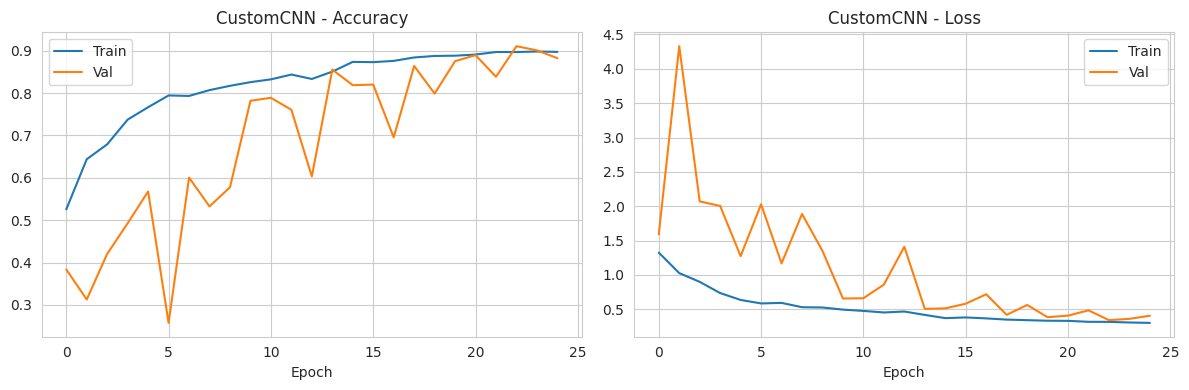

In [28]:
customcnn_history = customcnn_model.fit(customcnn_train_ds, validation_data=customcnn_val_ds, epochs=EPOCHS, callbacks=get_callbacks("customcnn"), verbose=1,)
plot_training_curves(customcnn_history, "CustomCNN")


##### Custom CNN — Evaluation



===== CustomCNN - Train Metrics =====
  accuracy: 0.2673
 precision: 0.2489
    recall: 0.2490
        f1: 0.2489

===== CustomCNN - Test Metrics =====
  accuracy: 0.9082
 precision: 0.9056
    recall: 0.9148
        f1: 0.9092

===== CustomCNN - Test Classification Report =====
              precision    recall  f1-score   support

      glioma       0.97      0.88      0.92       228
  meningioma       0.84      0.88      0.86       216
     notumor       0.87      0.94      0.91        88
   pituitary       0.94      0.95      0.95       198

    accuracy                           0.91       730
   macro avg       0.91      0.91      0.91       730
weighted avg       0.91      0.91      0.91       730



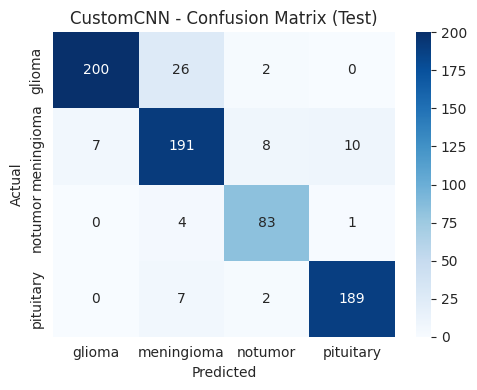


CustomCNN - Test ROC-AUC (macro, OvR): 0.9844


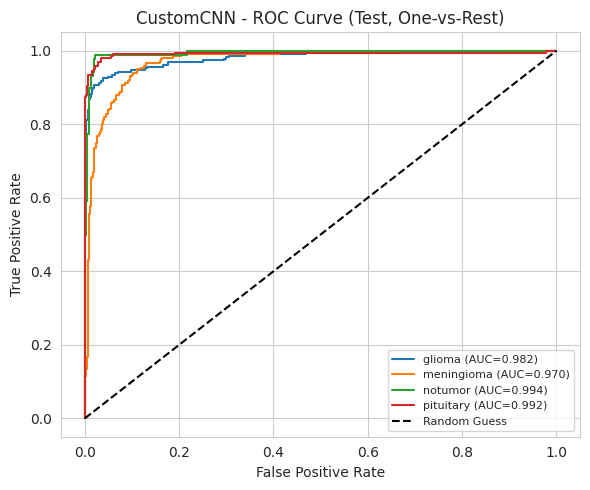

{'CustomCNN': {'split': 'test',
  'accuracy': 0.9082191780821918,
  'precision': 0.9056467709127892,
  'recall': 0.9147948786106681,
  'f1': 0.9091882897751558,
  'roc_auc': np.float64(0.9843748440600623)}}

In [29]:
customcnn_train_metrics, customcnn_test_metrics = full_evaluation(customcnn_model, "CustomCNN", customcnn_train_ds, customcnn_test_ds, train_df, test_df,)
all_results["CustomCNN"] = customcnn_test_metrics
all_results
